Loading model: gpt2


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6506.82it/s]


Total float params: 124,439,808
Global min: -11.050446510314941
Global max: 17.4193172454834


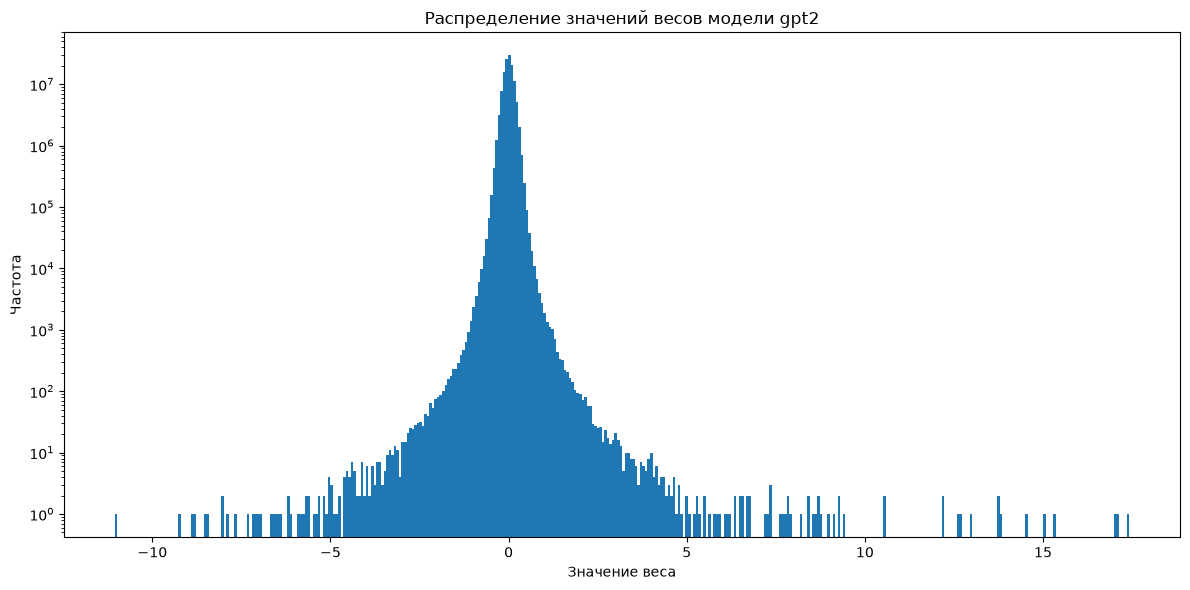

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel


def plot_gpt2_weight_histogram(
    model_name: str = "gpt2",
    bins: int = 400,
):
    print(f"Loading model: {model_name}")
    model = GPT2LMHeadModel.from_pretrained(model_name)
    model.eval()

    # 1. Находим глобальный min/max по всем float-параметрам
    global_min = None
    global_max = None
    total_params = 0

    for name, param in model.named_parameters():
        if not torch.is_floating_point(param):
            continue

        data = param.detach().cpu().float()
        pmin = float(data.min().item())
        pmax = float(data.max().item())

        global_min = pmin if global_min is None else min(global_min, pmin)
        global_max = pmax if global_max is None else max(global_max, pmax)
        total_params += data.numel()

    print(f"Total float params: {total_params:,}")
    print(f"Global min: {global_min}")
    print(f"Global max: {global_max}")

    # 2. Строим histogram по всем параметрам без giant torch.cat(...)
    edges = np.linspace(global_min, global_max, bins + 1)
    hist = np.zeros(bins, dtype=np.int64)

    for name, param in model.named_parameters():
        if not torch.is_floating_point(param):
            continue

        values = param.detach().cpu().float().numpy().ravel()
        counts, _ = np.histogram(values, bins=edges)
        hist += counts

    centers = (edges[:-1] + edges[1:]) / 2
    width = edges[1] - edges[0]

    # 3. Рисуем
    plt.figure(figsize=(12, 6))
    plt.bar(centers, hist, width=width)
    plt.yscale("log")
    plt.xlabel("Значение веса")
    plt.ylabel("Частота")
    plt.title(f"Распределение значений весов модели {model_name}")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    plot_gpt2_weight_histogram("gpt2", bins=400)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7901.09it/s]


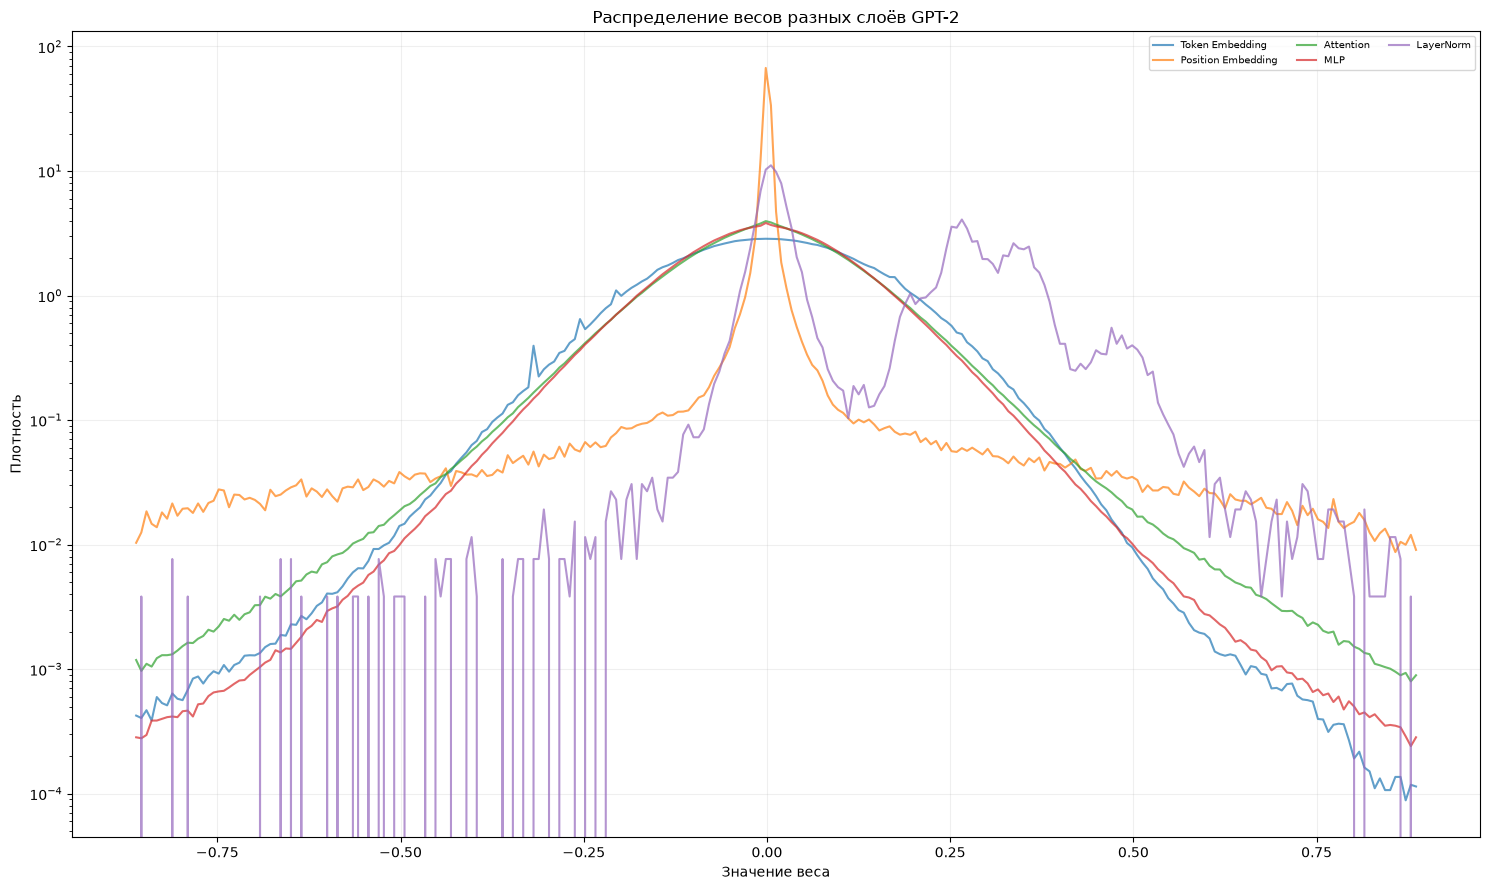

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel


model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()


def collect_weights(module):
    values = []

    for param in module.parameters():
        if torch.is_floating_point(param):
            values.append(
                param.detach().cpu().float().reshape(-1)
            )

    if not values:
        return np.array([])

    return torch.cat(values).numpy()


groups = {
    "Token Embedding": [],
    "Position Embedding": [],
    "Attention": [],
    "MLP": [],
    "LayerNorm": [],
}


groups["Token Embedding"].append(
    model.transformer.wte.weight.detach().cpu().float().reshape(-1)
)

groups["Position Embedding"].append(
    model.transformer.wpe.weight.detach().cpu().float().reshape(-1)
)


for block in model.transformer.h:
    for param in block.attn.parameters():
        groups["Attention"].append(
            param.detach().cpu().float().reshape(-1)
        )

    for param in block.mlp.parameters():
        groups["MLP"].append(
            param.detach().cpu().float().reshape(-1)
        )

    for ln in [block.ln_1, block.ln_2]:
        for param in ln.parameters():
            groups["LayerNorm"].append(
                param.detach().cpu().float().reshape(-1)
            )


for param in model.transformer.ln_f.parameters():
    groups["LayerNorm"].append(
        param.detach().cpu().float().reshape(-1)
    )


groups = {
    name: torch.cat(values).numpy()
    for name, values in groups.items()
}

# lm_head tied с token embedding у GPT-2,
# поэтому отдельно его можно не добавлять


# Общие bin edges, чтобы распределения можно было сравнивать
all_weights = np.concatenate([
    x for x in groups.values()
    if len(x) > 0
])

low = np.percentile(all_weights, 0.01)
high = np.percentile(all_weights, 99.99)

bins = np.linspace(low, high, 250)


plt.figure(figsize=(15, 9))

for name, weights in groups.items():
    hist, edges = np.histogram(
        weights,
        bins=bins,
        density=True,
    )

    centers = (edges[:-1] + edges[1:]) / 2

    plt.plot(
        centers,
        hist,
        label=name,
        alpha=0.7,
    )

plt.yscale("log")

plt.xlabel("Значение веса")
plt.ylabel("Плотность")
plt.title("Распределение весов разных слоёв GPT-2")

plt.legend(
    fontsize=7,
    ncol=3,
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [5]:
import torch
import pandas as pd
from transformers import GPT2LMHeadModel


model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()


def collect_group_weights(model):
    groups = {
        "Token Embedding": [],
        "Position Embedding": [],
        "Attention": [],
        "MLP": [],
        "LayerNorm": [],
    }

    groups["Token Embedding"].append(
        model.transformer.wte.weight.detach().cpu().float().reshape(-1)
    )

    groups["Position Embedding"].append(
        model.transformer.wpe.weight.detach().cpu().float().reshape(-1)
    )

    for block in model.transformer.h:
        for param in block.attn.parameters():
            groups["Attention"].append(
                param.detach().cpu().float().reshape(-1)
            )

        for param in block.mlp.parameters():
            groups["MLP"].append(
                param.detach().cpu().float().reshape(-1)
            )

        for ln in [block.ln_1, block.ln_2]:
            for param in ln.parameters():
                groups["LayerNorm"].append(
                    param.detach().cpu().float().reshape(-1)
                )

    for param in model.transformer.ln_f.parameters():
        groups["LayerNorm"].append(
            param.detach().cpu().float().reshape(-1)
        )

    return {
        name: torch.cat(values)
        for name, values in groups.items()
    }


groups = collect_group_weights(model)

thresholds = [
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
    0.75,
]


rows = []

for name, weights in groups.items():
    abs_weights = weights.abs()

    row = {
        "Layer": name,
        "N weights": len(weights),
        "mean": weights.mean().item(),
        "std": weights.std().item(),
        "min": weights.min().item(),
        "max": weights.max().item(),
    }

    for threshold in thresholds:
        fraction = (
            (abs_weights <= threshold)
            .float()
            .mean()
            .item()
            * 100
        )

        row[f"|w| <= {threshold}"] = fraction

    rows.append(row)


df = pd.DataFrame(rows)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(df.round(4))

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4976.05it/s]


                Layer  N weights    mean     std      min      max  |w| <= 0.01  |w| <= 0.02  |w| <= 0.05  |w| <= 0.1  |w| <= 0.2  |w| <= 0.3  |w| <= 0.5  |w| <= 0.75
0     Token Embedding   38597376  0.0004  0.1437  -1.2698   1.7852       5.7035      11.3851      27.9886     52.5492     84.2662     96.1398     99.8258      99.9856
1  Position Embedding     786432 -0.0007  0.1227  -4.5381   4.0653      79.2062      85.9144      90.9560     93.1562     95.0919     96.3235     97.9785      99.2495
2           Attention   28348416  0.0000  0.1363  -8.8818   8.7034       7.7542      15.0921      34.9661     60.8109     87.9460     96.5221     99.5670      99.9267
3                 MLP   56669184 -0.0015  0.1278 -11.0504  17.1023       7.4393      14.5843      34.6761     61.5345     89.2202     97.3929     99.8210      99.9739
4           LayerNorm      38400  0.1936  0.3452  -4.1918  17.4193      19.0651      32.1068      46.2083     49.3646     52.9896     74.5625     94.8828      96.513

Вот теперь у нас уже есть численный ответ, и он довольно сильный.

Для **почти всех основных весов GPT-2** диапазон `[-0.5, 0.5]` действительно покрывает практически всё:

| Группа | Доля весов с `|w| <= 0.5` |
|---|---:|
| Token Embedding | **99.826%** |
| Position Embedding | **97.979%** |
| Attention | **99.567%** |
| MLP | **99.821%** |
| LayerNorm | 94.883% |

Если взвесить все группы по числу параметров, то получается примерно:

> **99.75% всех float-весов GPT-2 находятся в диапазоне `[-0.5, 0.5]`.**

А в диапазоне:

* `[-0.3, 0.3]` — уже около **96.8%**;
* `[-0.2, 0.2]` — около **87.4%**;
* `[-0.1, 0.1]` — около **58.8%**.

То есть визуальная оценка с графика была правильной, но теперь она подтверждена количественно.

Самое интересное для нашей low-bit идеи — это MLP и Attention, потому что именно там огромная часть параметров:

```text
Attention: 28.35 млн
MLP:       56.67 млн
```

и при этом:

```text
Attention:
96.52%  в [-0.3, 0.3]
99.57%  в [-0.5, 0.5]

MLP:
97.39%  в [-0.3, 0.3]
99.82%  в [-0.5, 0.5]
```

Это уже очень хорошая структура для агрессивной квантизации.

Но есть важный момент: **сам диапазон [-0.5, 0.5] не означает, что нам нужны сотни уровней внутри него**. Для 2 бит у нас есть всего 4 состояния. Поэтому главный вопрос теперь не «какой диапазон весов?», а:

> **как лучше всего расположить 3–4 представимых значения внутри этого распределения?**

Например, очень грубая 2-bit схема:

```text
00 → -α
01 →  0
10 → +α
11 → special / second magnitude
```

или четырёхуровневая:

```text
{-α, -β, +β, +α}
```

где `α` и `β` подбираются не вручную, а минимизируют ошибку квантования для конкретного слоя.

И вот твои данные показывают, почему **один глобальный α для всей модели — скорее всего плохая идея**. Стандартные отклонения уже различаются:

```text
Token Embedding       std = 0.1437
Attention             std = 0.1363
MLP                   std = 0.1278
Position Embedding    std = 0.1227
LayerNorm             std = 0.3452
```

Особенно LayerNorm явно живёт отдельно — его я бы **вообще не трогал 2 битами**. Он занимает всего:

```text
38 400 параметров
```

на фоне примерно **124 млн параметров модели**. Экономия там бессмысленна.

То есть практически разумный первый вариант для Ocean:

```text
MLP weights            → 2 bit
Attention weights      → 2 bit
Token Embedding        → 2–4 bit экспериментально
Position Embedding     → отдельно проверить
LayerNorm              → FP16 / FP32
biases                 → FP16 / FP32
```

Причём MLP + Attention — это уже примерно **85 млн параметров**, так что именно там находится основная выгода.

Следующий эксперимент я бы сделал уже очень конкретным: взять GPT-2 и для `Attention` и `MLP` найти **оптимальные 2-bit уровни**, затем посчитать:

```text
MSE(original_weights, quantized_weights)
cosine similarity
max error
```

для трёх вариантов:

```text
ternary:       {-α, 0, +α}
4-level:       {-α, -β, +β, +α}
uniform int2:  4 равномерных уровня
```

Вот после этого мы уже сможем выбрать **реальный формат 2-bit весов для Ocean**, а не просто обсуждать диапазон.

Результат получился довольно однозначный: **для GPT-2 из трёх схем лучший вариант — оптимизированный симметричный 4-level quantizer** `{-α, -β, +β, +α}`. Он стабильно выигрывает и на Attention, и на MLP.

### Итоговые метрики

| Группа    | Схема                 |          MSE |     Cosine |        SQNR |
| --------- | --------------------- | -----------: | ---------: | ----------: |
| Attention | **4-level optimized** | **0.003047** | **0.9087** | **7.85 dB** |
| Attention | uniform int2          |     0.003826 |     0.8947 |     6.86 dB |
| Attention | ternary               |     0.004518 |     0.8752 |     6.14 dB |
| MLP       | **4-level optimized** | **0.002407** | **0.9253** | **8.31 dB** |
| MLP       | uniform int2          |     0.002882 |     0.9092 |     7.53 dB |
| MLP       | ternary               |     0.003645 |     0.8893 |     6.51 dB |

То есть в среднем optimized 4-level даёт примерно на **25–35% меньшую MSE**, чем ternary. Особенно хорошо он работает на MLP.

## Что особенно интересно

Тернарная схема действительно зануляет очень много весов. По отдельным слоям `zero_fraction` обычно находится примерно в диапазоне:

```text
~0.46–0.53    для большинства слоёв
```

а в отдельных ранних projection-слоях доходит до:

```text
0.68
0.86
```

То есть примерно **половину весов можно занулить**, если использовать `{−α,0,+α}`.

Это уже интересный результат не столько для dense 2-bit, сколько для **sparse ternary inference**.

Но для обычного packed dense веса:

```text
2 bit / weight
```

четыре ненулевых уровня выигрывают.

---

# Что получается для Ocean

Я бы сейчас **не делал ternary основной 2-bit схемой**.

Лучше сделать:

```text
Ocean Q2
========

code    value
00      -α
01      -β
10      +β
11      +α
```

где:

```text
0 < β < α
```

и `α`, `β` хранятся как scale metadata для группы весов.

Например, из твоих результатов для типичного MLP:

```text
β ≈ 0.058
α ≈ 0.195
```

а для Attention:

```text
β ≈ 0.057–0.065
α ≈ 0.19–0.24
```

То есть сами значения оказываются удивительно стабильными между большим количеством слоёв.

Это очень интересно.

---

# Но есть важнейшая проблема

Посмотри на `max_error`.

Например:

```text
MLP h.3 c_proj
max original ≈ 17
max_error after quantization ≈ 16.96
```

Или:

```text
Attention h.11 c_proj
max_error ≈ 8.60
```

Это означает, что наши редкие огромные outlier weights просто схлопываются в обычный `α`.

Именно поэтому у нас одновременно:

```text
cosine ≈ 0.92
```

но:

```text
max_error ≈ 17
```

То есть **bulk distribution мы описываем хорошо, а outliers — ужасно**.

И это, на мой взгляд, сейчас главный результат эксперимента.

---

# Значит, следующий формат должен быть не просто Q2

Нам нужен:

## **Q2 + outlier preservation**

Например:

```text
99.5–99.9% weights
        ↓
packed 2-bit
{-α, -β, +β, +α}

0.1–0.5% outliers
        ↓
FP16 sparse table
```

Получаем примерно:

```text
dense 2-bit matrix
+
tiny sparse FP16 correction
```

Это может быть гораздо сильнее простой 2-bit квантизации.

Например исходный вес:

```text
w = 17.10
```

в обычном Q2 превращается примерно в:

```text
0.31
```

ошибка:

```text
~16.8
```

А в hybrid:

```text
Q2 matrix:       0
outlier table:   17.10
```

или:

```text
Q2 approximation: 0.31
residual:          16.79
```

И при matmul:

```text
Y = X @ W_q2
  + X @ W_outliers
```

---

# Это особенно хорошо согласуется с твоим первым наблюдением

Мы установили:

```text
Attention:
99.567% weights ∈ [-0.5, 0.5]

MLP:
99.821% weights ∈ [-0.5, 0.5]
```

То есть outlier table потенциально будет совсем маленькой.

Для MLP:

```text
outside ±0.5 ≈ 0.179%
```

Для Attention:

```text
outside ±0.5 ≈ 0.433%
```

Поэтому концептуально:

```text
~99.6–99.8% weights → 2 bit
~0.2–0.4% weights   → FP16
```

выглядит очень привлекательно.

---

## Прикидка памяти

Допустим 100 млн весов.

FP32:

```text
100M × 4 bytes
= 400 MB
```

Чистый Q2:

```text
100M × 2 bits
= 25 MB
```

Это **16× compression** относительно FP32.

Если ещё 0.3% весов храним как FP16 outliers:

```text
300 000 × 2 bytes ≈ 0.6 MB
```

Плюс индексы. Даже если индекс занимает 4 байта:

```text
300 000 × (2 + 4)
≈ 1.8 MB
```

То есть условно:

```text
Q2             25 MB
outliers       ~2 MB
metadata       tiny
--------------------
total          ~27 MB
```

Всё равно около **15× меньше FP32**.

---

# Я бы сейчас тестировал уже четыре схемы

```text
1. Ternary
   {-α, 0, +α}

2. Uniform Q2
   {-s, -s/3, +s/3, +s}

3. Optimized Q2
   {-α, -β, +β, +α}

4. Optimized Q2 + FP16 outliers
   {-α, -β, +β, +α}
   + sparse residual/outlier table
```

И почти уверен, что **№4 резко поднимет cosine similarity**, потому что сейчас значительная часть ошибки MSE идёт именно из сравнительно небольшого числа экстремальных весов.

Следующий эксперимент я бы уже делал не по весовым MSE в вакууме, а **реально квантизировал GPT-2 и измерял perplexity на тексте**. Это даст ответ, может ли наш Ocean Q2 использоваться для настоящей LLM без retraining.